# Fuzzy Inference System (FIS) Mamdani
## Sistem Rekomendasi Laptop Berdasarkan Price, RAM, Storage, dan Weight

**Deskripsi:**  
Implementasi lengkap Fuzzy Inference System metode Mamdani untuk menghasilkan skor rekomendasi laptop (0–100).

**Variabel Input:**
| Variabel | Himpunan Fuzzy |
|-||
| Price    | Murah · Sedang · Mahal |
| RAM      | Kecil · Sedang · Besar |
| Storage  | Kecil · Sedang · Besar |
| Weight   | Ringan · Sedang · Berat |

**Variabel Output:** Kelayakan Laptop (Sangat Rendah · Rendah · Sedang · Tinggi · Sangat Tinggi)

**Metode:**  
`Fuzzification → Rule Evaluation (AND=MIN) → Aggregation (MAX) → Defuzzification (Centroid)`




## 1. Import Library

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, warnings
warnings.filterwarnings("ignore")

print("Library berhasil diimport")
print(f"   numpy   : {np.__version__}")
print(f"   pandas  : {pd.__version__}")


Library berhasil diimport
   numpy   : 2.4.4
   pandas  : 3.0.2


## 2. Pembacaan Dataset

Dataset laptop dibaca dari file CSV.  
Kolom yang digunakan sebagai variabel input FIS:
- `Price` — harga laptop (USD)
- `Ram_GB` — kapasitas RAM (GB)
- `Total_Storage_GB` — kapasitas storage (GB)
- `Weight_kg` — berat laptop (kg)


In [26]:
# ─────────────────────────────────────────────────────────
# LANGKAH 1: Pembacaan Data
# ─────────────────────────────────────────────────────────

DATASET_PATH = "./data/laptop_scrap_data.csv"

# Coba berbagai lokasi umum
candidate_paths = [
    DATASET_PATH,
    f"/mnt/user-data/uploads/{DATASET_PATH}",
    f"./{DATASET_PATH}",
]

df_raw = None
for path in candidate_paths:
    if os.path.exists(path):
        df_raw = pd.read_csv(path)
        print(f"Dataset ditemukan di: {path}")
        break

if df_raw is None:
    raise FileNotFoundError(
        f"File '{DATASET_PATH}' tidak ditemukan. "
        "Pastikan file CSV berada di direktori yang sama dengan notebook ini."
    )

print(f"\nUkuran dataset awal : {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom")
print(f"\n🔍 Kolom dataset:")
print(df_raw.dtypes.to_string())


Dataset ditemukan di: ./data/laptop_scrap_data.csv

Ukuran dataset awal : 1563 baris × 21 kolom

🔍 Kolom dataset:
Company                 str
TypeName                str
Inches              float64
ScreenResolution        str
Cpu                     str
Gpu                     str
OpSys                   str
TouchScreen         float64
Ips                 float64
X_res               float64
Y_res               float64
ppi                 float64
Dedicated_Gpu       float64
Ram_GB              float64
Weight_kg           float64
SSD                 float64
HHD                 float64
Storage_Type            str
Total_Storage_GB    float64
Storage_Category        str
Price               float64


## 3. Pembersihan Data

Sebelum masuk ke proses FIS, dataset harus dibersihkan dari nilai yang tidak valid:

| Kondisi yang dihapus | Alasan |
|-|--|
| `Price ≤ 0` | Harga tidak boleh nol atau negatif |
| `Ram_GB ≤ 0` | RAM 0 GB tidak valid secara teknis |
| `Total_Storage_GB ≤ 0` | Storage 0 GB tidak valid |
| `Weight_kg ≤ 0` | Berat 0 kg tidak masuk akal |
| Baris dengan NaN pada kolom penting | Data tidak lengkap |

> **Catatan:** Nilai 0 pada kolom-kolom ini kemungkinan besar adalah *missing value* yang dikodekan sebagai 0, bukan nilai sesungguhnya.


In [27]:
# ─────────────────────────────────────────────────────────
# LANGKAH 2: Pembersihan Data
# ─────────────────────────────────────────────────────────

KOLOM_PENTING = ['Price', 'Ram_GB', 'Total_Storage_GB', 'Weight_kg']

print("=" * 60)
print("LAPORAN PEMBERSIHAN DATA")
print("=" * 60)

df = df_raw.copy()

#  Step 2a: Cek missing value (NaN) 
nan_counts = df[KOLOM_PENTING].isnull().sum()
print("\n[Step 2a] Missing value (NaN) pada kolom penting:")
for col in KOLOM_PENTING:
    print(f"  {col:<22} : {nan_counts[col]:>5} NaN")

before_nan = len(df)
df = df.dropna(subset=KOLOM_PENTING)
dropped_nan = before_nan - len(df)
print(f"  → Baris dihapus karena NaN : {dropped_nan}")

#  Step 2b: Hapus nilai 0 pada kolom penting 
print("\n[Step 2b] Nilai 0 (invalid) pada kolom penting:")
for col in KOLOM_PENTING:
    n_zero = (df[col] <= 0).sum()
    print(f"  {col:<22} : {n_zero:>5} baris dengan nilai ≤ 0")

before_zero = len(df)
mask_valid = (
    (df['Price']            > 0) &
    (df['Ram_GB']           > 0) &
    (df['Total_Storage_GB'] > 0) &
    (df['Weight_kg']        > 0)
)
df = df[mask_valid].reset_index(drop=True)
dropped_zero = before_zero - len(df)
print(f"  → Baris dihapus karena nilai ≤ 0 : {dropped_zero}")

total_dropped = len(df_raw) - len(df)
print(f"\n{'─'*40}")
print(f"  Data awal          : {len(df_raw):>6} baris")
print(f"  Total data dihapus : {total_dropped:>6} baris")
print(f"  Data tersisa       : {len(df):>6} baris  ← akan digunakan untuk FIS")
print(f"{'─'*40}")

# Statistik dasar kolom penting setelah pembersihan
print("\nStatistik Kolom Penting (setelah pembersihan):")
print(df[KOLOM_PENTING].describe().round(2).to_string())

print("\nPembersihan data selesai — dataset siap untuk proses FIS")


LAPORAN PEMBERSIHAN DATA

[Step 2a] Missing value (NaN) pada kolom penting:
  Price                  :     3 NaN
  Ram_GB                 :     3 NaN
  Total_Storage_GB       :     3 NaN
  Weight_kg              :     3 NaN
  → Baris dihapus karena NaN : 3

[Step 2b] Nilai 0 (invalid) pada kolom penting:
  Price                  :     0 baris dengan nilai ≤ 0
  Ram_GB                 :     0 baris dengan nilai ≤ 0
  Total_Storage_GB       :     1 baris dengan nilai ≤ 0
  Weight_kg              :    11 baris dengan nilai ≤ 0
  → Baris dihapus karena nilai ≤ 0 : 12

────────────────────────────────────────
  Data awal          :   1563 baris
  Total data dihapus :     15 baris
  Data tersisa       :   1548 baris  ← akan digunakan untuk FIS
────────────────────────────────────────

Statistik Kolom Penting (setelah pembersihan):
         Price   Ram_GB  Total_Storage_GB  Weight_kg
count  1548.00  1548.00           1548.00    1548.00
mean   1939.20    29.09           1406.78       1.80
std 

## 4. Fungsi Keanggotaan Input

Setiap variabel input didefinisikan dengan tiga himpunan fuzzy menggunakan fungsi linear (trapesium/segitiga).


In [28]:
# ─────────────────────────────────────────────────────────
# LANGKAH 3: Definisi Fungsi Keanggotaan Input
# ─────────────────────────────────────────────────────────

#  HARGA (Price) 
def price_murah(x):
    """Murah: 1.0 jika ≤1200, turun linier ke 0 di 1800."""
    if x <= 1200: return 1.0
    elif x < 1800: return (1800 - x) / 600
    else: return 0.0

def price_sedang(x):
    """Sedang: naik 1200→1800, turun 1800→2600."""
    if x <= 1200 or x >= 2600: return 0.0
    elif x < 1800: return (x - 1200) / 600
    elif x < 2600: return (2600 - x) / 800
    else: return 0.0

def price_mahal(x):
    """Mahal: naik linier 2000→3000, 1.0 jika ≥3000."""
    if x <= 2000: return 0.0
    elif x < 3000: return (x - 2000) / 1000
    else: return 1.0


#  RAM 
def ram_kecil(x):
    """Kecil: 1.0 jika ≤8 GB, turun ke 0 di 16 GB."""
    if x <= 8: return 1.0
    elif x < 16: return (16 - x) / 8
    else: return 0.0

def ram_sedang(x):
    """Sedang: naik 8→24, turun 24→40 GB."""
    if x <= 8 or x >= 40: return 0.0
    elif x < 24: return (x - 8) / 16
    elif x < 40: return (40 - x) / 16
    else: return 0.0

def ram_besar(x):
    """Besar: naik linier 24→64 GB, 1.0 jika ≥64 GB."""
    if x <= 24: return 0.0
    elif x < 64: return (x - 24) / 40
    else: return 1.0


#  WEIGHT 
def weight_ringan(x):
    """Ringan: 1.0 jika ≤1.5 kg, turun ke 0 di 2.0 kg."""
    if x <= 1.5: return 1.0
    elif x < 2.0: return (2.0 - x) / 0.5
    else: return 0.0

def weight_sedang(x):
    """Sedang: naik 1.3→1.8, turun 1.8→2.3 kg."""
    if x <= 1.3 or x >= 2.3: return 0.0
    elif x < 1.8: return (x - 1.3) / 0.5
    elif x < 2.3: return (2.3 - x) / 0.5
    else: return 0.0

def weight_berat(x):
    """Berat: naik linier 1.8→2.5 kg, 1.0 jika ≥2.5 kg."""
    if x <= 1.8: return 0.0
    elif x < 2.5: return (x - 1.8) / 0.7
    else: return 1.0


#  STORAGE 
def storage_kecil(x):
    """Kecil: 1.0 jika ≤512 GB, turun ke 0 di 1000 GB."""
    if x <= 512: return 1.0
    elif x < 1000: return (1000 - x) / 488
    else: return 0.0

def storage_sedang(x):
    """Sedang: naik 512→1000, turun 1000→2000 GB."""
    if x <= 512 or x >= 2000: return 0.0
    elif x < 1000: return (x - 512) / 488
    elif x < 2000: return (2000 - x) / 1000
    else: return 0.0

def storage_besar(x):
    """Besar: naik linier 1000→3000 GB, 1.0 jika ≥3000 GB."""
    if x <= 1000: return 0.0
    elif x < 3000: return (x - 1000) / 2000
    else: return 1.0

print("Fungsi keanggotaan input berhasil didefinisikan")
print("   Price   : murah · sedang · mahal")
print("   RAM     : kecil · sedang · besar")
print("   Storage : kecil · sedang · besar")
print("   Weight  : ringan · sedang · berat")


Fungsi keanggotaan input berhasil didefinisikan
   Price   : murah · sedang · mahal
   RAM     : kecil · sedang · besar
   Storage : kecil · sedang · besar
   Weight  : ringan · sedang · berat


## 5. Fungsi Keanggotaan Output — Kelayakan Laptop

Domain output: **[0, 100]**  
Lima himpunan fuzzy yang overlap dan mencakup seluruh domain.


In [29]:
# ─────────────────────────────────────────────────────────
# LANGKAH 4: Definisi Fungsi Keanggotaan Output
# ─────────────────────────────────────────────────────────

def output_sangat_rendah(y):
    """Sangat Rendah: trapesium, 1.0 di [0,10], turun ke 0 di 30."""
    if y <= 10: return 1.0
    elif y < 30: return (30 - y) / 20
    else: return 0.0

def output_rendah(y):
    """Rendah: segitiga, naik 10→25, turun 25→45."""
    if y <= 10 or y >= 45: return 0.0
    elif y < 25: return (y - 10) / 15
    elif y < 45: return (45 - y) / 20
    else: return 0.0

def output_sedang(y):
    """Sedang: segitiga simetris, puncak di 50, domain 30-70."""
    if y <= 30 or y >= 70: return 0.0
    elif y < 50: return (y - 30) / 20
    elif y < 70: return (70 - y) / 20
    else: return 0.0

def output_tinggi(y):
    """Tinggi: segitiga, naik 55→72, turun 72→90."""
    if y <= 55 or y >= 90: return 0.0
    elif y < 72: return (y - 55) / 17
    elif y < 90: return (90 - y) / 18
    else: return 0.0

def output_sangat_tinggi(y):
    """Sangat Tinggi: trapesium, naik 75→90, 1.0 di [90,100]."""
    if y <= 75: return 0.0
    elif y < 90: return (y - 75) / 15
    else: return 1.0

# Dictionary output MF
OUTPUT_MF = {
    "sangat_rendah": output_sangat_rendah,
    "rendah":        output_rendah,
    "sedang":        output_sedang,
    "tinggi":        output_tinggi,
    "sangat_tinggi": output_sangat_tinggi,
}

print("Fungsi keanggotaan output berhasil didefinisikan")
print("   Kelayakan : Sangat Rendah · Rendah · Sedang · Tinggi · Sangat Tinggi")


Fungsi keanggotaan output berhasil didefinisikan
   Kelayakan : Sangat Rendah · Rendah · Sedang · Tinggi · Sangat Tinggi


## 6. Rule Base Mamdani (27 Rules)

Setiap rule menggunakan operator **AND = MIN**.  
`None` pada antecedent berarti kondisi tersebut tidak menjadi syarat rule.

**Prinsip desain:**
- Harga murah → lebih disukai
- RAM besar → lebih disukai  
- Storage besar → lebih disukai
- Weight ringan → lebih disukai


In [30]:
# ─────────────────────────────────────────────────────────
# LANGKAH 5: Rule Base Mamdani
# Format: (price_lbl, ram_lbl, storage_lbl, weight_lbl, output_lbl)
# None = kondisi tidak digunakan dalam rule tersebut
# ─────────────────────────────────────────────────────────

RULES = [
    # SANGAT TINGGI
    # R01: Murah + RAM Besar + Storage Besar + Ringan
    ("murah",  "besar",  "besar",  "ringan",  "sangat_tinggi"),
    # R02: Murah + RAM Besar + Storage Besar + Sedang
    ("murah",  "besar",  "besar",  "sedang",  "sangat_tinggi"),
    # R03: Sedang + RAM Besar + Storage Besar + Ringan
    ("sedang", "besar",  "besar",  "ringan",  "sangat_tinggi"),
    # R04: Murah + RAM Sedang + Storage Besar + Ringan
    ("murah",  "sedang", "besar",  "ringan",  "sangat_tinggi"),

    # TINGGI
    # R05: Murah + RAM Besar + Storage Sedang + Ringan
    ("murah",  "besar",  "sedang", "ringan",  "tinggi"),
    # R06: Sedang + RAM Besar + Storage Sedang + Ringan
    ("sedang", "besar",  "sedang", "ringan",  "tinggi"),
    # R07: Murah + RAM Sedang + Storage Sedang + Ringan
    ("murah",  "sedang", "sedang", "ringan",  "tinggi"),
    # R08: Murah + RAM Besar + Storage Besar + Berat
    ("murah",  "besar",  "besar",  "berat",   "tinggi"),
    # R09: Sedang + RAM Besar + Storage Besar + Sedang
    ("sedang", "besar",  "besar",  "sedang",  "tinggi"),
    # R10: Murah + RAM Sedang + Storage Besar + Sedang
    ("murah",  "sedang", "besar",  "sedang",  "tinggi"),
    # R11: Sedang + RAM Sedang + Storage Besar + Ringan
    ("sedang", "sedang", "besar",  "ringan",  "tinggi"),

    # SEDANG
    # R12: Murah + RAM Kecil + Storage Sedang + Ringan
    ("murah",  "kecil",  "sedang", "ringan",  "sedang"),
    # R13: Sedang + RAM Sedang + Storage Sedang + Sedang
    ("sedang", "sedang", "sedang", "sedang",  "sedang"),
    # R14: Mahal + RAM Besar + Storage Besar + Ringan
    ("mahal",  "besar",  "besar",  "ringan",  "sedang"),
    # R15: Sedang + RAM Kecil + Storage Sedang + Ringan
    ("sedang", "kecil",  "sedang", "ringan",  "sedang"),
    # R16: Murah + RAM Sedang + Storage Kecil + Ringan
    ("murah",  "sedang", "kecil",  "ringan",  "sedang"),
    # R17: Sedang + RAM Besar + Storage Sedang + Berat
    ("sedang", "besar",  "sedang", "berat",   "sedang"),
    # R18: Mahal + RAM Besar + Storage Besar + Sedang
    ("mahal",  "besar",  "besar",  "sedang",  "sedang"),
    # R19: Sedang + RAM Sedang + Storage Sedang + Berat
    ("sedang", "sedang", "sedang", "berat",   "sedang"),

    # RENDAH
    # R20: Mahal + RAM Kecil + Storage Kecil + Berat
    ("mahal",  "kecil",  "kecil",  "berat",   "rendah"),
    # R21: Mahal + RAM Sedang + Storage Kecil + Sedang
    ("mahal",  "sedang", "kecil",  "sedang",  "rendah"),
    # R22: Sedang + RAM Kecil + Storage Kecil + Berat
    ("sedang", "kecil",  "kecil",  "berat",   "rendah"),
    # R23: Mahal + RAM Kecil + Storage Sedang + Berat
    ("mahal",  "kecil",  "sedang", "berat",   "rendah"),
    # R24: Mahal + RAM Sedang + Storage Sedang + Berat
    ("mahal",  "sedang", "sedang", "berat",   "rendah"),

    # SANGAT RENDAH
    # R25: Mahal + RAM Kecil + Storage Kecil + Berat
    ("mahal",  "kecil",  "kecil",  "berat",   "sangat_rendah"),
    # R26: Mahal + RAM Kecil + Berat (storage bebas)
    ("mahal",  "kecil",  None,     "berat",   "sangat_rendah"),
    # R27: Mahal + Storage Kecil + Berat (RAM bebas)
    ("mahal",  None,     "kecil",  "berat",   "sangat_rendah"),
]

print(f"Rule base berhasil didefinisikan: {len(RULES)} rules")
print()

# Ringkasan per kategori output
from collections import Counter
output_counts = Counter(r[4] for r in RULES)
for label in ["sangat_tinggi", "tinggi", "sedang", "rendah", "sangat_rendah"]:
    bar = "█" * output_counts[label]
    print(f"  {label:<16} : {output_counts[label]:>2} rules  {bar}")


Rule base berhasil didefinisikan: 27 rules

  sangat_tinggi    :  4 rules  ████
  tinggi           :  7 rules  ███████
  sedang           :  8 rules  ████████
  rendah           :  5 rules  █████
  sangat_rendah    :  3 rules  ███


## 7. Pipeline FIS Mamdani

### Tahapan:
1. **Fuzzification** — menghitung μ setiap variabel input  
2. **Rule Evaluation** — firing strength = MIN antecedents (operator AND)  
3. **Aggregation** — gabungkan output semua rule dengan MAX  
4. **Defuzzification** — Centroid: `∑(y · μ(y)) / ∑μ(y)`


In [31]:
# ─────────────────────────────────────────────────────────
# LANGKAH 6: Pipeline Inferensi Mamdani
# ─────────────────────────────────────────────────────────

#  Pemetaan label: nama kunci dict membership 
PRICE_MF   = {"murah": "price_murah",    "sedang": "price_sedang",    "mahal": "price_mahal"}
RAM_MF     = {"kecil": "ram_kecil",      "sedang": "ram_sedang",      "besar": "ram_besar"}
STORAGE_MF = {"kecil": "storage_kecil",  "sedang": "storage_sedang",  "besar": "storage_besar"}
WEIGHT_MF  = {"ringan": "weight_ringan", "sedang": "weight_sedang",   "berat": "weight_berat"}


def fuzzify(price, ram, storage, weight):
    """
    Fuzzification: menghitung derajat keanggotaan semua variabel input.

    Returns dict dengan 12 nilai μ (0–1).
    """
    return {
        "price_murah":    price_murah(price),
        "price_sedang":   price_sedang(price),
        "price_mahal":    price_mahal(price),
        "ram_kecil":      ram_kecil(ram),
        "ram_sedang":     ram_sedang(ram),
        "ram_besar":      ram_besar(ram),
        "storage_kecil":  storage_kecil(storage),
        "storage_sedang": storage_sedang(storage),
        "storage_besar":  storage_besar(storage),
        "weight_ringan":  weight_ringan(weight),
        "weight_sedang":  weight_sedang(weight),
        "weight_berat":   weight_berat(weight),
    }


def evaluate_rules(membership):
    """
    Rule Evaluation + Aggregation.

    AND = MIN  → firing_strength = min(antecedents)
    Aggregasi antar rule = MAX (untuk output yang sama)

    Returns dict: {output_label: max_firing_strength}
    """
    fired = {label: 0.0 for label in OUTPUT_MF}

    for (price_lbl, ram_lbl, storage_lbl, weight_lbl, output_lbl) in RULES:
        antecedents = []
        if price_lbl   is not None: antecedents.append(membership[PRICE_MF[price_lbl]])
        if ram_lbl     is not None: antecedents.append(membership[RAM_MF[ram_lbl]])
        if storage_lbl is not None: antecedents.append(membership[STORAGE_MF[storage_lbl]])
        if weight_lbl  is not None: antecedents.append(membership[WEIGHT_MF[weight_lbl]])

        fs = min(antecedents) if antecedents else 0.0
        fired[output_lbl] = max(fired[output_lbl], fs)   # Agregasi MAX

    return fired


def defuzzify_centroid(fired, n_points=500):
    """
    Defuzzifikasi Centroid (Center of Gravity).

    Untuk setiap titik y di [0,100]:
      1. Hitung μ_clipped(y) = MIN(firing_strength, μ_output(y)) 
      2. Agregasi: μ_agg(y)  = MAX dari semua kontribusi output

    Centroid: z* = ∑(y · μ_agg(y)) / ∑μ_agg(y)
    """
    y_vals     = np.linspace(0, 100, n_points)
    aggregated = np.zeros(n_points)

    for i, y in enumerate(y_vals):
        contributions = [
            min(strength, OUTPUT_MF[label](y))
            for label, strength in fired.items()
            if strength > 0
        ]
        aggregated[i] = max(contributions) if contributions else 0.0

    denom = np.sum(aggregated)
    return float(np.sum(y_vals * aggregated) / denom) if denom > 0 else 0.0


def fis_score(price, ram, storage, weight):
    """
    Pipeline lengkap FIS Mamdani untuk satu laptop.
    Returns float skor rekomendasi (0–100).
    """
    membership = fuzzify(price, ram, storage, weight)
    fired      = evaluate_rules(membership)
    return      defuzzify_centroid(fired)


print("Pipeline FIS Mamdani berhasil didefinisikan:")
print("   fuzzify()           → derajat keanggotaan input")
print("   evaluate_rules()    → firing strength setiap output")
print("   defuzzify_centroid()→ skor defuzzifikasi")
print("   fis_score()         → pipeline lengkap (satu laptop)")


Pipeline FIS Mamdani berhasil didefinisikan:
   fuzzify()           → derajat keanggotaan input
   evaluate_rules()    → firing strength setiap output
   defuzzify_centroid()→ skor defuzzifikasi
   fis_score()         → pipeline lengkap (satu laptop)


## 8. Demonstrasi: FIS untuk Satu Laptop

Contoh trace lengkap semua tahapan FIS pada satu laptop sampel.


In [32]:
# ─────────────────────────────────────────────────────────
# DEMO: Trace FIS satu laptop
# ─────────────────────────────────────────────────────────

# Ambil laptop pertama dari dataset yang sudah bersih
sample = df.iloc[0]
P = float(sample['Price'])
R = float(sample['Ram_GB'])
S = float(sample['Total_Storage_GB'])
W = float(sample['Weight_kg'])

print(f"Laptop  : {sample['TypeName']}")
print(f"Harga   : ${P:,.2f}")
print(f"RAM     : {R} GB")
print(f"Storage : {S} GB")
print(f"Weight  : {W} kg")

# Step 1: Fuzzification
mship = fuzzify(P, R, S, W)
print("\n─── Step 1: Fuzzification ────────────────────────")
for k, v in mship.items():
    bar = "█" * int(v * 20)
    print(f"  μ({k:<18}) = {v:.4f}  {bar}")

# Step 2: Rule Evaluation + Aggregation
fired_strengths = evaluate_rules(mship)
print("\n─── Step 2+3: Rule Evaluation & Aggregation ─────")
for label, fs in fired_strengths.items():
    bar = "█" * int(fs * 20)
    print(f"  Firing [{label:<16}] = {fs:.4f}  {bar}")

# Step 3: Defuzzification
score = defuzzify_centroid(fired_strengths)
print(f"\n─── Step 4: Defuzzifikasi Centroid ───────────────")
print(f"  Skor Rekomendasi = {score:.4f}")

# Interpretasi
if score < 30:    kategori = "Sangat Rendah"
elif score < 45:  kategori = "Rendah"
elif score < 60:  kategori = "Sedang"
elif score < 75:  kategori = "Tinggi"
else:             kategori = "Sangat Tinggi"
print(f"  Kategori         = {kategori}")


Laptop  : MSI Prestige 16 AI+
Harga   : $2,728.80
RAM     : 64.0 GB
Storage : 1000.0 GB
Weight  : 1.59 kg

─── Step 1: Fuzzification ────────────────────────
  μ(price_murah       ) = 0.0000  
  μ(price_sedang      ) = 0.0000  
  μ(price_mahal       ) = 0.7288  ██████████████
  μ(ram_kecil         ) = 0.0000  
  μ(ram_sedang        ) = 0.0000  
  μ(ram_besar         ) = 1.0000  ████████████████████
  μ(storage_kecil     ) = 0.0000  
  μ(storage_sedang    ) = 1.0000  ████████████████████
  μ(storage_besar     ) = 0.0000  
  μ(weight_ringan     ) = 0.8200  ████████████████
  μ(weight_sedang     ) = 0.5800  ███████████
  μ(weight_berat      ) = 0.0000  

─── Step 2+3: Rule Evaluation & Aggregation ─────
  Firing [sangat_rendah   ] = 0.0000  
  Firing [rendah          ] = 0.0000  
  Firing [sedang          ] = 0.0000  
  Firing [tinggi          ] = 0.0000  
  Firing [sangat_tinggi   ] = 0.0000  

─── Step 4: Defuzzifikasi Centroid ───────────────
  Skor Rekomendasi = 0.0000
  Kategori     

## 9. Hitung Skor Seluruh Dataset & Ranking


In [33]:
# ─────────────────────────────────────────────────────────
# LANGKAH 7: Proses seluruh dataset
# ─────────────────────────────────────────────────────────

print(f"Memproses {len(df)} laptop... ", end="", flush=True)

scores = []
for idx, row in df.iterrows():
    scores.append(fis_score(
        price   = float(row['Price']),
        ram     = float(row['Ram_GB']),
        storage = float(row['Total_Storage_GB']),
        weight  = float(row['Weight_kg'])
    ))
    if (len(scores)) % 300 == 0:
        print(f"{len(scores)}", end=" ", flush=True)

df['recommendation_score'] = scores

# Ranking descending
df = df.sort_values('recommendation_score', ascending=False).reset_index(drop=True)
df['rank'] = df.index + 1

# Kategorisasi
bins   = [0, 30, 45, 60, 75, 100]
labels = ['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']
df['kategori'] = pd.cut(df['recommendation_score'], bins=bins, labels=labels, include_lowest=True)

print(f"\n\nSelesai!")
print(f"\nStatistik Skor Rekomendasi:")
print(f"  Tertinggi  : {df['recommendation_score'].max():.4f}")
print(f"  Terendah   : {df['recommendation_score'].min():.4f}")
print(f"  Rata-rata  : {df['recommendation_score'].mean():.4f}")
print(f"  Median     : {df['recommendation_score'].median():.4f}")
print(f"  Std dev    : {df['recommendation_score'].std():.4f}")

print(f"\nDistribusi Kategori:")
cat_counts = df['kategori'].value_counts()
for lbl in labels:
    cnt = cat_counts.get(lbl, 0)
    pct = cnt / len(df) * 100
    bar = "█" * int(pct / 2)
    print(f"  {lbl:<16} : {cnt:>5} laptop ({pct:5.1f}%)  {bar}")


Memproses 1548 laptop... 300 600 900 1200 1500 

Selesai!

Statistik Skor Rekomendasi:
  Tertinggi  : 86.7389
  Terendah   : 0.0000
  Rata-rata  : 41.8415
  Median     : 50.0000
  Std dev    : 26.7537

Distribusi Kategori:
  Sangat Rendah    :   428 laptop ( 27.6%)  █████████████
  Rendah           :     0 laptop (  0.0%)  
  Sedang           :   742 laptop ( 47.9%)  ███████████████████████
  Tinggi           :   322 laptop ( 20.8%)  ██████████
  Sangat Tinggi    :    56 laptop (  3.6%)  █


## 10. Hasil Ranking Laptop

In [34]:
DISPLAY_COLS = ['rank', 'TypeName', 'recommendation_score', 'Price', 'Ram_GB',
                'Total_Storage_GB', 'Weight_kg', 'kategori']

print("=" * 80)
print("TOP 10 LAPTOP TERBAIK")
print("=" * 80)
top10 = df[DISPLAY_COLS].head(10)
top10_display = top10.copy()
top10_display['recommendation_score'] = top10_display['recommendation_score'].round(2)
print(top10_display.to_string(index=False))

print("\n" + "=" * 80)
print("BOTTOM 5 LAPTOP (Skor Terendah)")
print("=" * 80)
bot5 = df[DISPLAY_COLS].tail(5)
bot5_display = bot5.copy()
bot5_display['recommendation_score'] = bot5_display['recommendation_score'].round(2)
print(bot5_display.to_string(index=False))


TOP 10 LAPTOP TERBAIK
 rank                  TypeName  recommendation_score  Price  Ram_GB  Total_Storage_GB  Weight_kg      kategori
    1     Dell Inspiron 15 3535                 86.74 1239.0    48.0            2000.0       1.66 Sangat Tinggi
    2     Dell Inspiron 15 3535                 81.84 1409.0    48.0            4000.0       1.66 Sangat Tinggi
    3      HP 250 G10 / 255 G10                 80.02 1099.0    32.0            2000.0       1.52 Sangat Tinggi
    4     Dell Inspiron 15 3535                 79.60  839.0    16.0            2000.0       1.66 Sangat Tinggi
    5     Dell Inspiron 15 3535                 79.60  939.0    24.0            2000.0       1.66 Sangat Tinggi
    6     Dell Inspiron 15 3535                 79.60 1269.0    32.0            4000.0       1.66 Sangat Tinggi
    7     Dell Inspiron 15 3535                 79.60 1039.0    32.0            2000.0       1.66 Sangat Tinggi
    8     Dell Inspiron 15 3535                 79.60  889.0    16.0            20

## 11. Visualisasi

Tujuh plot disajikan dalam satu figure:
1. MF Harga  
2. MF RAM  
3. MF Storage  
4. MF Weight  
5. MF Output Kelayakan  
6. Histogram distribusi skor  
7. Bar chart Top 10 laptop


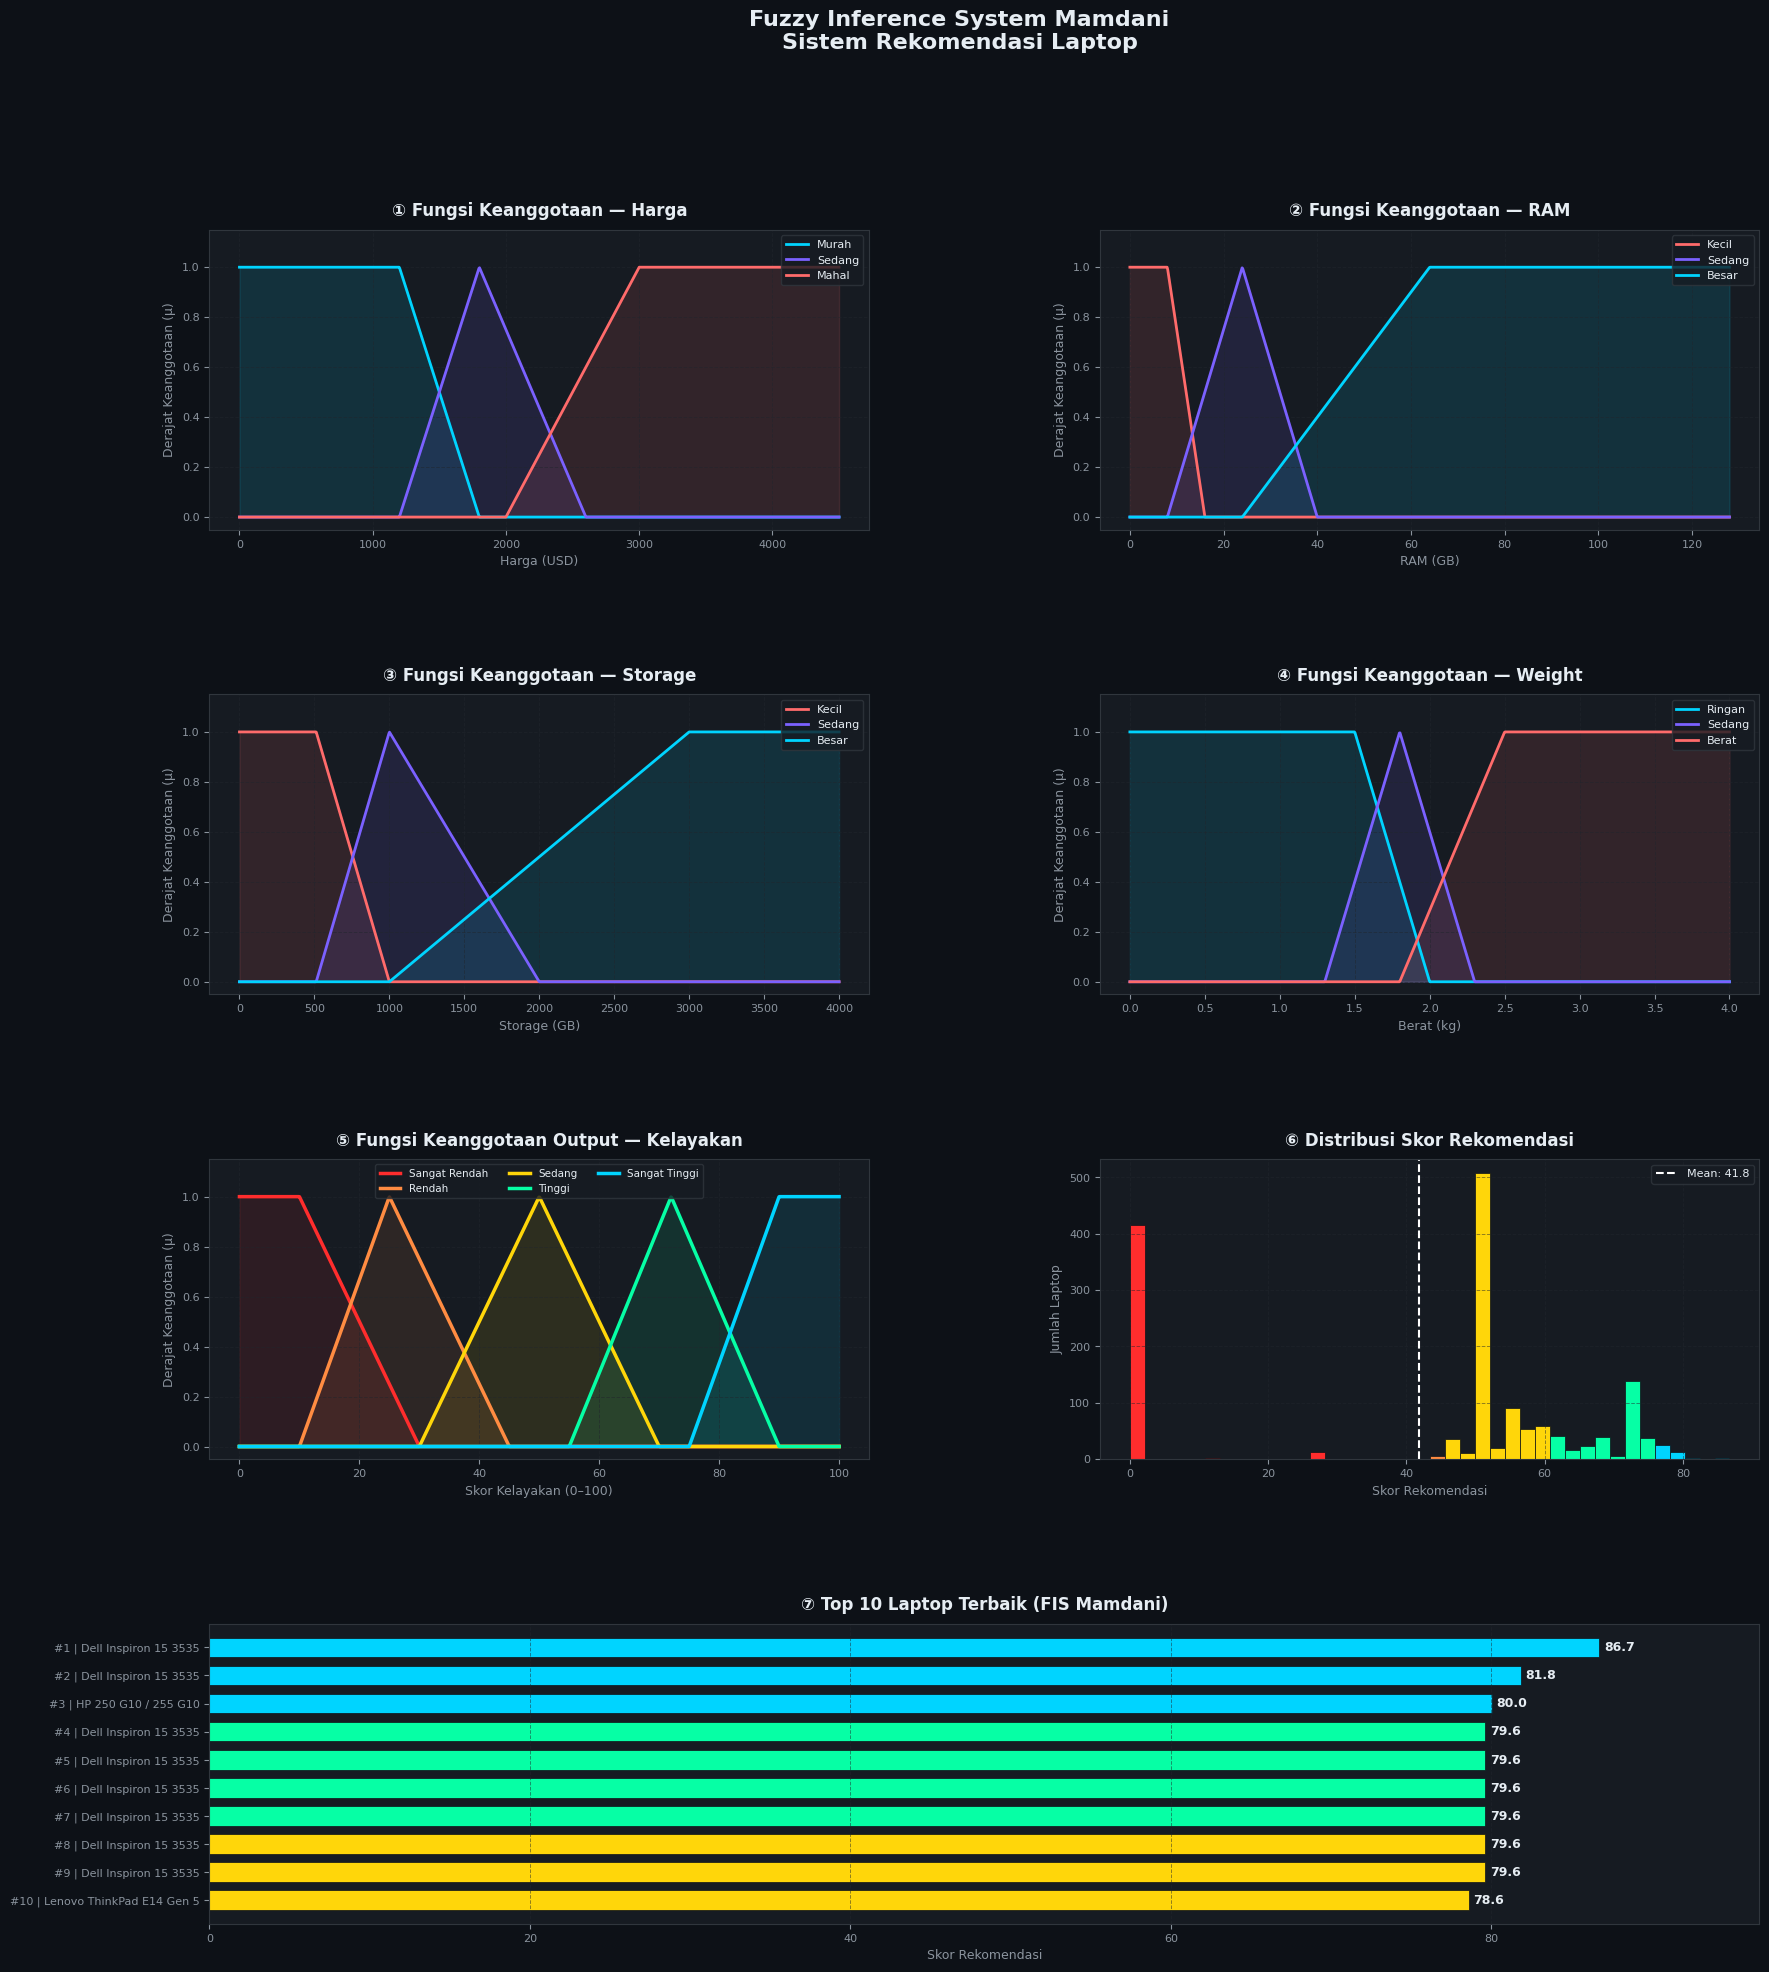

Visualisasi selesai (juga disimpan sebagai fis_mamdani_visualisasi.png)


In [35]:
# ─────────────────────────────────────────────────────────
# LANGKAH 8: Visualisasi
# ─────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor('#0d1117')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.35)

C = {
    'murah':  '#00d4ff', 'sedang_p': '#7b61ff', 'mahal': '#ff6b6b',
    'kecil':  '#ff6b6b', 'sedang_r': '#7b61ff', 'besar': '#00d4ff',
    'ringan': '#00d4ff', 'sedang_w': '#7b61ff', 'berat': '#ff6b6b',
    'SR': '#ff2d2d', 'R': '#ff8c42', 'S': '#ffd60a', 'T': '#06ffa5', 'ST': '#00d4ff',
}
BG, EDGE, TC, LC, GC = '#161b22', '#30363d', '#e6edf3', '#8b949e', '#21262d'

def style(ax, title, xlabel, ylabel='Derajat Keanggotaan (μ)'):
    ax.set_facecolor(BG)
    for sp in ax.spines.values(): sp.set_edgecolor(EDGE)
    ax.set_title(title, color=TC, fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(xlabel, color=LC, fontsize=9)
    ax.set_ylabel(ylabel, color=LC, fontsize=9)
    ax.tick_params(colors=LC, labelsize=8)
    ax.grid(True, color=GC, linestyle='--', alpha=0.5, lw=0.7)
    ax.set_ylim(-0.05, 1.15)
    leg = ax.legend(fontsize=8, facecolor=BG, edgecolor=EDGE, labelcolor=TC, loc='upper right')

# ── Plot 1: Harga ──
ax1 = fig.add_subplot(gs[0, 0])
xp = np.linspace(0, 4500, 1000)
for fn, lbl, col in [(price_murah, 'Murah', C['murah']),
                     (price_sedang,'Sedang',C['sedang_p']),
                     (price_mahal, 'Mahal', C['mahal'])]:
    y = [fn(x) for x in xp]
    ax1.plot(xp, y, color=col, lw=2, label=lbl)
    ax1.fill_between(xp, y, alpha=0.12, color=col)
style(ax1, '① Fungsi Keanggotaan — Harga', 'Harga (USD)')

# ── Plot 2: RAM ──
ax2 = fig.add_subplot(gs[0, 1])
xr = np.linspace(0, 128, 1000)
for fn, lbl, col in [(ram_kecil, 'Kecil', C['kecil']),
                     (ram_sedang,'Sedang',C['sedang_r']),
                     (ram_besar, 'Besar', C['besar'])]:
    y = [fn(x) for x in xr]
    ax2.plot(xr, y, color=col, lw=2, label=lbl)
    ax2.fill_between(xr, y, alpha=0.12, color=col)
style(ax2, '② Fungsi Keanggotaan — RAM', 'RAM (GB)')

# ── Plot 3: Storage ──
ax3 = fig.add_subplot(gs[1, 0])
xs = np.linspace(0, 4000, 1000)
for fn, lbl, col in [(storage_kecil, 'Kecil', C['kecil']),
                     (storage_sedang,'Sedang',C['sedang_r']),
                     (storage_besar, 'Besar', C['besar'])]:
    y = [fn(x) for x in xs]
    ax3.plot(xs, y, color=col, lw=2, label=lbl)
    ax3.fill_between(xs, y, alpha=0.12, color=col)
style(ax3, '③ Fungsi Keanggotaan — Storage', 'Storage (GB)')

# ── Plot 4: Weight ──
ax4 = fig.add_subplot(gs[1, 1])
xw = np.linspace(0, 4, 1000)
for fn, lbl, col in [(weight_ringan,'Ringan',C['ringan']),
                     (weight_sedang,'Sedang',C['sedang_w']),
                     (weight_berat, 'Berat', C['berat'])]:
    y = [fn(x) for x in xw]
    ax4.plot(xw, y, color=col, lw=2, label=lbl)
    ax4.fill_between(xw, y, alpha=0.12, color=col)
style(ax4, '④ Fungsi Keanggotaan — Weight', 'Berat (kg)')

# ── Plot 5: Output Kelayakan ──
ax5 = fig.add_subplot(gs[2, 0])
yo = np.linspace(0, 100, 1000)
for fn, lbl, col in [(output_sangat_rendah,'Sangat Rendah',C['SR']),
                     (output_rendah,       'Rendah',       C['R']),
                     (output_sedang,       'Sedang',       C['S']),
                     (output_tinggi,       'Tinggi',       C['T']),
                     (output_sangat_tinggi,'Sangat Tinggi',C['ST'])]:
    y = [fn(x) for x in yo]
    ax5.plot(yo, y, color=col, lw=2.5, label=lbl)
    ax5.fill_between(yo, y, alpha=0.10, color=col)
ax5.set_facecolor(BG)
for sp in ax5.spines.values(): sp.set_edgecolor(EDGE)
ax5.set_title('⑤ Fungsi Keanggotaan Output — Kelayakan', color=TC, fontsize=12, fontweight='bold', pad=10)
ax5.set_xlabel('Skor Kelayakan (0–100)', color=LC, fontsize=9)
ax5.set_ylabel('Derajat Keanggotaan (μ)', color=LC, fontsize=9)
ax5.tick_params(colors=LC, labelsize=8)
ax5.grid(True, color=GC, linestyle='--', alpha=0.5, lw=0.7)
ax5.set_ylim(-0.05, 1.15)
ax5.legend(fontsize=7.5, facecolor=BG, edgecolor=EDGE, labelcolor=TC, loc='upper center', ncol=3)

# ── Plot 6: Histogram ──
ax6 = fig.add_subplot(gs[2, 1])
ax6.set_facecolor(BG)
for sp in ax6.spines.values(): sp.set_edgecolor(EDGE)
n, bins, patches = ax6.hist(df['recommendation_score'], bins=40, edgecolor='#0d1117', lw=0.5)
bin_colors = {0: C['SR'], 1: C['R'], 2: C['S'], 3: C['T'], 4: C['ST']}
color_bins = [0, 30, 45, 60, 75, 100]
for patch, left in zip(patches, bins):
    mid = left + (bins[1]-bins[0])/2
    idx = next((i for i, b in enumerate(color_bins[1:]) if mid < b), 4)
    patch.set_facecolor(list(bin_colors.values())[idx])
mean_score = df['recommendation_score'].mean()
ax6.axvline(mean_score, color='white', linestyle='--', lw=1.5, label=f'Mean: {mean_score:.1f}')
ax6.set_title('⑥ Distribusi Skor Rekomendasi', color=TC, fontsize=12, fontweight='bold', pad=10)
ax6.set_xlabel('Skor Rekomendasi', color=LC, fontsize=9)
ax6.set_ylabel('Jumlah Laptop', color=LC, fontsize=9)
ax6.tick_params(colors=LC, labelsize=8)
ax6.grid(True, color=GC, linestyle='--', alpha=0.5, lw=0.7)
ax6.legend(fontsize=8, facecolor=BG, edgecolor=EDGE, labelcolor=TC)

# ── Plot 7: Top 10 ──
ax7 = fig.add_subplot(gs[3, :])
ax7.set_facecolor(BG)
for sp in ax7.spines.values(): sp.set_edgecolor(EDGE)
top10_plot = df.head(10).copy()
top10_plot['short_name'] = top10_plot['TypeName'].str[:30]
ypos = np.arange(10)
svals = top10_plot['recommendation_score'].values
bcolors = [C['ST']]*3 + [C['T']]*4 + [C['S']]*3
ax7.barh(ypos, svals[::-1], color=bcolors[::-1], edgecolor='#0d1117', lw=0.5, height=0.7)
for i, (v, s) in enumerate(zip(ypos, svals[::-1])):
    ax7.text(s + 0.3, i, f'{s:.1f}', va='center', ha='left', color=TC, fontsize=9, fontweight='bold')
ax7.set_yticks(ypos)
ylabels = [f"#{int(r['rank'])} | {r['short_name']}" for _, r in top10_plot.iloc[::-1].iterrows()]
ax7.set_yticklabels(ylabels, fontsize=8.5, color=TC)
ax7.set_xlabel('Skor Rekomendasi', color=LC, fontsize=9)
ax7.set_title('⑦ Top 10 Laptop Terbaik (FIS Mamdani)', color=TC, fontsize=12, fontweight='bold', pad=10)
ax7.tick_params(colors=LC, labelsize=8)
ax7.grid(True, color=GC, linestyle='--', alpha=0.5, lw=0.7, axis='x')
ax7.set_xlim(0, svals.max() + 10)

fig.suptitle('Fuzzy Inference System Mamdani\nSistem Rekomendasi Laptop',
             color='#e6edf3', fontsize=16, fontweight='bold', y=0.98)

plt.savefig('fis_mamdani_visualisasi.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117', edgecolor='none')
plt.show()
print("Visualisasi selesai (juga disimpan sebagai fis_mamdani_visualisasi.png)")


## 12. Ekspor Hasil Ranking ke CSV

In [36]:
# ─────────────────────────────────────────────────────────
# LANGKAH 9: Simpan hasil ke CSV
# ─────────────────────────────────────────────────────────

out_cols = ['rank', 'TypeName', 'Company', 'recommendation_score',
            'Price', 'Ram_GB', 'Total_Storage_GB', 'Weight_kg', 'kategori']
out_cols = [c for c in out_cols if c in df.columns]

output_csv = 'laptop_ranking_fis.csv'
df[out_cols].to_csv(output_csv, index=False)

print(f"Hasil ranking disimpan ke: {output_csv}")
print(f"   Total baris : {len(df)}")
print(f"   Kolom       : {out_cols}")


Hasil ranking disimpan ke: laptop_ranking_fis.csv
   Total baris : 1548
   Kolom       : ['rank', 'TypeName', 'Company', 'recommendation_score', 'Price', 'Ram_GB', 'Total_Storage_GB', 'Weight_kg', 'kategori']


## 13. Dokumentasi Ilmiah



### 13.1 Konsep Fuzzy Inference System Mamdani

Fuzzy Inference System (FIS) Mamdani adalah metode penalaran berbasis aturan fuzzy yang diperkenalkan oleh Mamdani & Assilian (1975). Berbeda dengan logika biner (ya/tidak), logika fuzzy memungkinkan nilai keanggotaan kontinu antara 0 dan 1, sehingga mampu merepresentasikan ketidakpastian dan gradasi konsep linguistik seperti "murah", "cukup", atau "mahal".

Dalam sistem ini, keputusan diambil berdasarkan inferensi dari sekumpulan **aturan IF-THEN** yang mencerminkan pengetahuan pakar (expert knowledge).



### 13.2 Fungsi Keanggotaan yang Digunakan

**Variabel Input:**

| Variabel | Himpunan | Tipe | Batas |
|-|-||-|
| Price | Murah | Trapesium kiri | ≤1200 penuh, turun ke 0 di 1800 |
| Price | Sedang | Segitiga | naik 1200→1800, turun 1800→2600 |
| Price | Mahal | Trapesium kanan | naik 2000→3000, ≥3000 penuh |
| RAM | Kecil | Trapesium kiri | ≤8 GB penuh |
| RAM | Sedang | Segitiga | puncak di 24 GB |
| RAM | Besar | Trapesium kanan | ≥64 GB penuh |
| Storage | Kecil | Trapesium kiri | ≤512 GB penuh |
| Storage | Sedang | Segitiga | puncak di 1000 GB |
| Storage | Besar | Trapesium kanan | ≥3000 GB penuh |
| Weight | Ringan | Trapesium kiri | ≤1.5 kg penuh |
| Weight | Sedang | Segitiga | puncak di 1.8 kg |
| Weight | Berat | Trapesium kanan | ≥2.5 kg penuh |

**Variabel Output (Kelayakan Laptop):**

| Himpunan | Tipe | Domain |
|-||--|
| Sangat Rendah | Trapesium kiri | 0–30 |
| Rendah | Segitiga | 10–45, puncak 25 |
| Sedang | Segitiga | 30–70, puncak 50 |
| Tinggi | Segitiga | 55–90, puncak 72 |
| Sangat Tinggi | Trapesium kanan | 75–100 |



### 13.3 Rule Base

Rule base dirancang berdasarkan prinsip:
- **Harga murah** lebih disukai → mendorong skor ke atas
- **RAM besar** lebih disukai → performa komputasi lebih baik
- **Storage besar** lebih disukai → kapasitas penyimpanan lebih luas
- **Weight ringan** lebih disukai → portabilitas lebih tinggi

Total: **27 rules** yang terdistribusi ke 5 kategori output.



### 13.4 Firing Strength

Firing strength (α) mengukur seberapa kuat sebuah rule terpenuhi:

```
α = MIN(μ_price(x₁), μ_ram(x₂), μ_storage(x₃), μ_weight(x₄))
```

Operator MIN digunakan karena semua kondisi dalam satu rule harus terpenuhi (konjungsi AND). Semakin tinggi firing strength, semakin kuat kontribusi rule tersebut terhadap keputusan akhir.



### 13.5 Agregasi Output

Untuk menggabungkan kontribusi semua rule yang menuju output yang sama, digunakan operator **MAX**:

```
μ_agg(y) = MAX(α₁·μ_out1(y), α₂·μ_out2(y), ..., αn·μ_outn(y))
```

Ini memastikan bahwa jika lebih dari satu rule mendukung suatu kategori, yang terkuat yang diambil.



### 13.6 Defuzzifikasi Centroid

Metode Centroid (Center of Gravity) mengubah kurva fuzzy agregat menjadi satu nilai crisp:

```
z* = ∑(yᵢ · μ_agg(yᵢ)) / ∑μ_agg(yᵢ)
```

Domain [0,100] didiskretisasi menjadi 500 titik. Metode ini menghasilkan nilai yang stabil dan memperhitungkan seluruh bentuk kurva agregasi.



### 13.7 Interpretasi Skor Rekomendasi

| Rentang Skor | Kategori | Interpretasi |
|-|-|-|
| 0 – 30 | Sangat Rendah | Tidak direkomendasikan (mahal + berat + RAM/Storage kecil) |
| 30 – 45 | Rendah | Kurang direkomendasikan |
| 45 – 60 | Sedang | Cukup layak, ada trade-off |
| 60 – 75 | Tinggi | Direkomendasikan |
| 75 – 100 | Sangat Tinggi | Sangat direkomendasikan (murah + ringan + RAM/Storage besar) |



### 13.8 Analisis Hasil Ranking

Laptop-laptop yang menduduki ranking teratas umumnya memiliki karakteristik:
- Harga di bawah $1,500 (masuk himpunan "murah" penuh atau sebagian)
- RAM ≥ 32 GB (masuk himpunan "besar")
- Storage ≥ 2 TB (masuk himpunan "besar" atau "sedang-besar")
- Berat 1.5–1.7 kg (masuk himpunan "ringan" atau "ringan-sedang")

Laptop gaming premium (berat, mahal) mendapat skor rendah meski memiliki spesifikasi tinggi, karena sistem ini dioptimalkan untuk *value-for-money* dan portabilitas — bukan performa gaming murni.



### 13.9 Kelebihan dan Keterbatasan

**Kelebihan:**
- Interpretable: setiap rule dapat dijelaskan dalam bahasa natural
- Robust terhadap noise dan ketidakpastian data
- Tidak memerlukan data training (berbasis pengetahuan pakar)
- Dapat dimodifikasi dengan menambah/mengubah rule

**Keterbatasan:**
- Rule base bersifat subjektif (bergantung definisi pakar)
- Tidak beradaptasi secara otomatis dari data (perlu dikombinasikan dengan ANFIS untuk adaptive FIS)
- Fungsi keanggotaan didesain berdasarkan rentang harga tertentu — perlu dikalibrasi ulang jika pasar berubah signifikan
- Variabel lain yang relevan (CPU tier, GPU, layar) tidak dimasukkan dalam sistem ini
